
# Cyclistic Bike-Share — Analyze Phase

**Business question:** How do annual members and casual riders use Cyclistic bikes differently?

This notebook continues from the completed **Process** phase and uses the cleaned, analysis-ready dataset to perform descriptive analysis, identify trends and relationships, and prepare summary outputs for Power BI or presentation use.

## What this notebook does
- Loads the cleaned dataset from `02_Processed_Data`
- Verifies the analysis-ready structure
- Calculates core KPIs by rider type
- Analyzes patterns by month, day of week, and hour of day
- Compares ride duration distributions, bike type usage, and round-trip behavior
- Profiles top stations and high-opportunity casual-heavy stations
- Creates a simple **conversion opportunity** segment for commuter-like casual riders
- Exports summary tables and chart images for the Share phase


## Process-phase handoff
The Process documentation established that the cleaned dataset contains:
- **5,439,188 rows**
- **28 columns**
- valid ride lengths from **1.00 to 239.97 minutes**
- date coverage from **2025-03-01 to 2026-02-28**
- member categories limited to **member** and **casual**
- bike types limited to **classic_bike** and **electric_bike**

In [2]:

# --- Imports ---
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- Project paths ---
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "03_Scripts" else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_ROOT / "02_Processed_Data"
VIS_DIR = PROJECT_ROOT / "05_Visualizations" / "analysis_exports"
SUMMARY_DIR = PROCESSED_DIR / "analysis_outputs"

VIS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data dir:", PROCESSED_DIR)
print("Visualization export dir:", VIS_DIR)
print("Summary export dir:", SUMMARY_DIR)


Project root: c:\Users\John Lloyd Legaspi\Documents\Projects\Cyclistic_Bike_Share
Processed data dir: c:\Users\John Lloyd Legaspi\Documents\Projects\Cyclistic_Bike_Share\02_Processed_Data
Visualization export dir: c:\Users\John Lloyd Legaspi\Documents\Projects\Cyclistic_Bike_Share\05_Visualizations\analysis_exports
Summary export dir: c:\Users\John Lloyd Legaspi\Documents\Projects\Cyclistic_Bike_Share\02_Processed_Data\analysis_outputs


In [3]:

# --- Load cleaned dataset ---
parquet_path = PROCESSED_DIR / "cyclistic_final_cleaned.parquet"
csv_path = PROCESSED_DIR / "cyclistic_final_cleaned.csv"

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
    source_used = parquet_path.name
elif csv_path.exists():
    df = pd.read_csv(csv_path, low_memory=False)
    source_used = csv_path.name
else:
    raise FileNotFoundError(
        "Could not find cyclistic_final_cleaned.parquet or cyclistic_final_cleaned.csv in ../02_Processed_Data"
    )

print(f"Loaded {source_used}")
print(f"Shape: {df.shape}")
df.head()


Loaded cyclistic_final_cleaned.parquet
Shape: (5439162, 28)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file,ride_length,ride_date,ride_month,month_name,ride_day,day_of_week,day_name,ride_hour,is_weekend,is_round_trip,is_missing_coords,is_impossible_dur,dur_category,missing_coords
0,16CBE9844D401954,electric_bike,2025-03-18 08:39:20.065,2025-03-18 08:51:37.633,<NA>,<NA>,Canal St & Jackson Blvd,13138,41.91,-87.67,41.88,-87.64,member,202503-divvy-tripdata.csv,12.29,2025-03-18,3,March,18,3,Tuesday,8,False,False,False,False,Normal,False
1,1CB408029E2B5F74,electric_bike,2025-03-24 16:04:22.239,2025-03-24 16:27:41.347,<NA>,<NA>,Albany Ave & Bloomingdale Ave,15655,41.86,-87.68,41.91,-87.71,member,202503-divvy-tripdata.csv,23.32,2025-03-24,3,March,24,2,Monday,16,False,False,False,False,Normal,False
2,7B6A76CD0F204D08,electric_bike,2025-03-10 16:06:19.708,2025-03-10 16:29:17.457,<NA>,<NA>,Albany Ave & Bloomingdale Ave,15655,41.86,-87.68,41.91,-87.71,member,202503-divvy-tripdata.csv,22.96,2025-03-10,3,March,10,2,Monday,16,False,False,False,False,Normal,False
3,4F7084E3D75CDE31,electric_bike,2025-03-21 14:28:14.579,2025-03-21 14:35:06.160,<NA>,<NA>,Canal St & Jackson Blvd,13138,41.87,-87.63,41.88,-87.64,member,202503-divvy-tripdata.csv,6.86,2025-03-21,3,March,21,6,Friday,14,False,False,False,False,Normal,False
4,E419A570A5A0475B,electric_bike,2025-03-14 17:54:14.484,2025-03-14 18:17:53.254,<NA>,<NA>,Albany Ave & Bloomingdale Ave,15655,41.89,-87.67,41.91,-87.71,casual,202503-divvy-tripdata.csv,23.65,2025-03-14,3,March,14,6,Friday,17,False,False,False,False,Normal,False


In [4]:

# --- Normalize/verify expected analysis fields ---
for col in ["started_at", "ended_at", "ride_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

for bool_col in ["is_weekend", "is_round_trip"]:
    if bool_col in df.columns and df[bool_col].dtype == "object":
        df[bool_col] = (
            df[bool_col].astype(str).str.strip().str.lower()
            .map({"true": True, "false": False})
        )

if "ride_length" not in df.columns and {"started_at", "ended_at"}.issubset(df.columns):
    df["ride_length"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

if "ride_date" not in df.columns and "started_at" in df.columns:
    df["ride_date"] = df["started_at"].dt.floor("D")

if "ride_month" not in df.columns and "ride_date" in df.columns:
    df["ride_month"] = df["ride_date"].dt.month

if "month_name" not in df.columns and "ride_date" in df.columns:
    df["month_name"] = df["ride_date"].dt.month_name()

if "ride_day" not in df.columns and "ride_date" in df.columns:
    df["ride_day"] = df["ride_date"].dt.day

if "day_name" not in df.columns and "ride_date" in df.columns:
    df["day_name"] = df["ride_date"].dt.day_name()

if "ride_hour" not in df.columns and "started_at" in df.columns:
    df["ride_hour"] = df["started_at"].dt.hour

if "is_weekend" not in df.columns and "day_name" in df.columns:
    df["is_weekend"] = df["day_name"].isin(["Saturday", "Sunday"])

if "day_of_week" not in df.columns and "ride_date" in df.columns:
    python_dow = df["ride_date"].dt.dayofweek  # Monday=0
    df["day_of_week"] = ((python_dow + 1) % 7) + 1  # Sunday=1, Saturday=7

if "is_round_trip" not in df.columns and {"start_station_name", "end_station_name"}.issubset(df.columns):
    df["is_round_trip"] = (
        df["start_station_name"].fillna("").astype(str).str.strip()
        == df["end_station_name"].fillna("").astype(str).str.strip()
    )

expected_min_cols = [
    "member_casual", "rideable_type", "ride_length", "ride_date", "ride_month",
    "month_name", "ride_day", "day_of_week", "day_name", "ride_hour",
    "is_weekend", "is_round_trip"
]

missing = [c for c in expected_min_cols if c not in df.columns]
if missing:
    print("Warning: still missing expected columns:", missing)
else:
    print("All core analysis fields are available.")

df[expected_min_cols].head()


All core analysis fields are available.


,member_casual,rideable_type,ride_length,ride_date,ride_month,month_name,ride_day,day_of_week,day_name,ride_hour,is_weekend,is_round_trip
0,member,electric_bike,12.29,2025-03-18,3,March,18,3,Tuesday,8,False,False
1,member,electric_bike,23.32,2025-03-24,3,March,24,2,Monday,16,False,False
2,member,electric_bike,22.96,2025-03-10,3,March,10,2,Monday,16,False,False
3,member,electric_bike,6.86,2025-03-21,3,March,21,6,Friday,14,False,False
4,casual,electric_bike,23.65,2025-03-14,3,March,14,6,Friday,17,False,False



## Dataset overview and analysis sanity checks

Start by confirming the basic structure of the cleaned dataset:
- row and column count
- date range
- valid rider categories
- valid bike types
- key null counts in analysis fields

This confirms the dataset is ready for descriptive analysis.


In [5]:

# --- Basic validation for Analyze phase ---
overview = {
    "row_count": int(len(df)),
    "column_count": int(df.shape[1]),
    "date_min": str(pd.to_datetime(df["ride_date"]).min().date()) if "ride_date" in df.columns else None,
    "date_max": str(pd.to_datetime(df["ride_date"]).max().date()) if "ride_date" in df.columns else None,
    "member_categories": sorted(df["member_casual"].dropna().astype(str).unique().tolist()) if "member_casual" in df.columns else [],
    "rideable_types": sorted(df["rideable_type"].dropna().astype(str).unique().tolist()) if "rideable_type" in df.columns else [],
}
overview_df = pd.DataFrame(list(overview.items()), columns=["metric", "value"])
display(overview_df)

analysis_cols = [c for c in ["member_casual", "rideable_type", "ride_length", "ride_date", "day_name", "ride_hour", "is_weekend", "is_round_trip"] if c in df.columns]
nulls = df[analysis_cols].isna().sum().rename("null_count").to_frame()
nulls["null_pct"] = (nulls["null_count"] / len(df)) * 100
display(nulls)


,metric,value
0,row_count,5439162
1,column_count,28
2,date_min,2025-03-01
3,date_max,2026-02-28
4,member_categories,"[casual, member]"
5,rideable_types,"[classic_bike, electric_bike]"


,null_count,null_pct
member_casual,0,0.00
rideable_type,0,0.00
ride_length,0,0.00
ride_date,0,0.00
day_name,0,0.00
ride_hour,0,0.00
is_weekend,0,0.00
is_round_trip,0,0.00



## Core KPI comparison: members vs casual riders

This section answers the most basic analytical questions:
- Who takes more trips?
- Who rides longer?
- What share of total trips belongs to each rider type?

I did **not** rely only on averages. Median ride length is included because ride-duration data tends to be skewed.


In [12]:

# --- Core KPI summary by rider type ---
kpi_summary = (
    df.groupby("member_casual")
      .agg(
          total_trips=("member_casual", "size"),
          avg_ride_minutes=("ride_length", "mean"),
          median_ride_minutes=("ride_length", "median"),
          weekend_share=("is_weekend", "mean"),
          round_trip_share=("is_round_trip", "mean"),
      )
      .reset_index()
)

kpi_summary["trip_share_pct"] = (kpi_summary["total_trips"] / kpi_summary["total_trips"].sum() * 100)
kpi_summary["weekend_share"] = kpi_summary["weekend_share"] * 100
kpi_summary["round_trip_share"] = kpi_summary["round_trip_share"] * 100

kpi_summary = kpi_summary[
    ["member_casual", "total_trips", "trip_share_pct", "avg_ride_minutes",
     "median_ride_minutes", "weekend_share", "round_trip_share"]
].sort_values("total_trips", ascending=False)

display(kpi_summary.round(2))
kpi_summary.to_csv(SUMMARY_DIR / "kpi_summary_by_rider_type.csv", index=False)


,member_casual,total_trips,trip_share_pct,avg_ride_minutes,median_ride_minutes,weekend_share,round_trip_share
1,member,3514069,64.61,11.81,8.75,23.22,9.87
0,casual,1925093,35.39,18.55,11.86,37.12,15.45


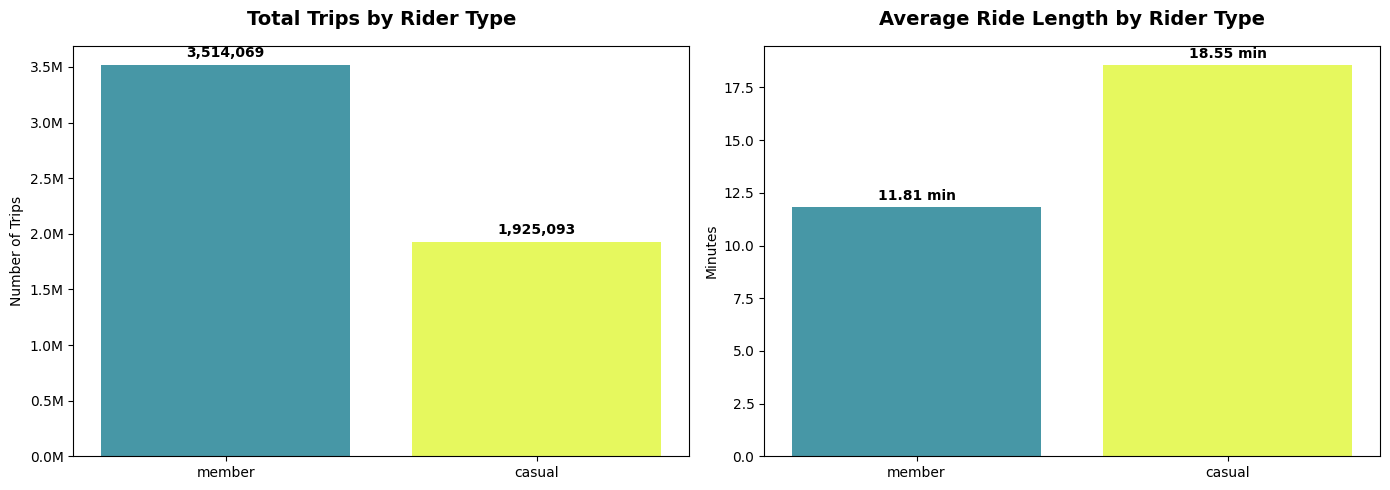

In [18]:
colors = ['#4797A6', '#E6F85E']

# --- Comparison Chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total Trips Chart
bars0 = axes[0].bar(kpi_summary["member_casual"], kpi_summary["total_trips"], color=colors)
axes[0].set_title("Total Trips by Rider Type", fontsize=14, pad=15, fontweight='bold')
axes[0].set_ylabel("Number of Trips")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M"))

# Add Data Labels for Trips 
for bar in bars0:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 50000,
                 f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# 2. Average Ride Length Chart
bars1 = axes[1].bar(kpi_summary["member_casual"], kpi_summary["avg_ride_minutes"], color=colors)
axes[1].set_title("Average Ride Length by Rider Type", fontsize=14, pad=15, fontweight='bold')
axes[1].set_ylabel("Minutes")

# Add Data Labels for Minutes
for bar in bars1:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.2,
                 f'{height:.2f} min', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Monthly and seasonal patterns

These visuals help answer:
- Are casual riders more seasonal?
- Are members more stable month-to-month?
- How does the member/casual mix change during warmer months?


In [15]:
# --- Monthly trip volume and average ride length ---
if "ride_date" in df.columns:
    df["year_month"] = pd.to_datetime(df["ride_date"]).dt.to_period("M").astype(str)

monthly_trips = (
    df.groupby(["year_month", "member_casual"])
      .size()
      .reset_index(name="total_trips")
)

monthly_trips_pivot = monthly_trips.pivot(index="year_month", columns="member_casual", values="total_trips").fillna(0)
monthly_trips_pivot["total"] = monthly_trips_pivot.sum(axis=1)

if "casual" in monthly_trips_pivot.columns:
    monthly_trips_pivot["casual_share_pct"] = monthly_trips_pivot["casual"] / monthly_trips_pivot["total"] * 100
if "member" in monthly_trips_pivot.columns:
    monthly_trips_pivot["member_share_pct"] = monthly_trips_pivot["member"] / monthly_trips_pivot["total"] * 100

monthly_avg = (
    df.groupby(["year_month", "member_casual"])["ride_length"]
      .mean()
      .reset_index(name="avg_ride_minutes")
)

display(monthly_trips_pivot.reset_index().head())
display(monthly_avg.head())

monthly_trips_pivot.reset_index().to_csv(SUMMARY_DIR / "monthly_trip_summary.csv", index=False)
monthly_avg.to_csv(SUMMARY_DIR / "monthly_avg_ride_length.csv", index=False)


member_casual,year_month,casual,member,total,casual_share_pct,member_share_pct
0,2025-03,82709,208307,291016,28.42,71.58
1,2025-04,105057,257775,362832,28.95,71.05
2,2025-05,175230,313840,489070,35.83,64.17
3,2025-06,277983,379332,657315,42.29,57.71
4,2025-07,307693,430042,737735,41.71,58.29


,year_month,member_casual,avg_ride_minutes
0,2025-03,casual,16.46
1,2025-03,member,10.83
2,2025-04,casual,17.33
3,2025-04,member,11.01
4,2025-05,casual,19.33


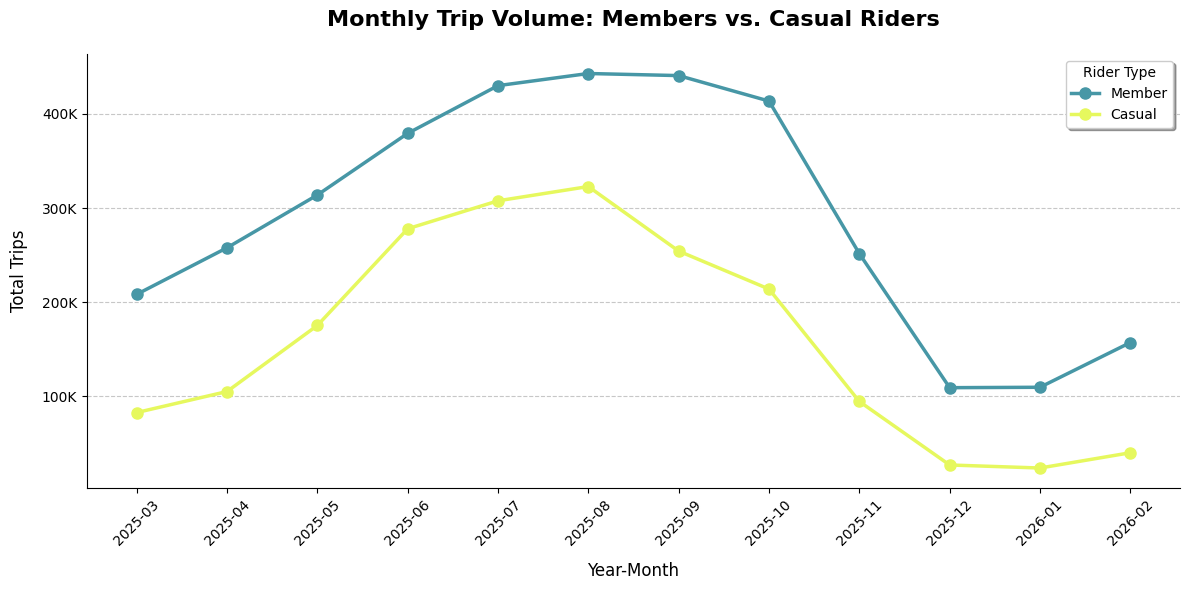

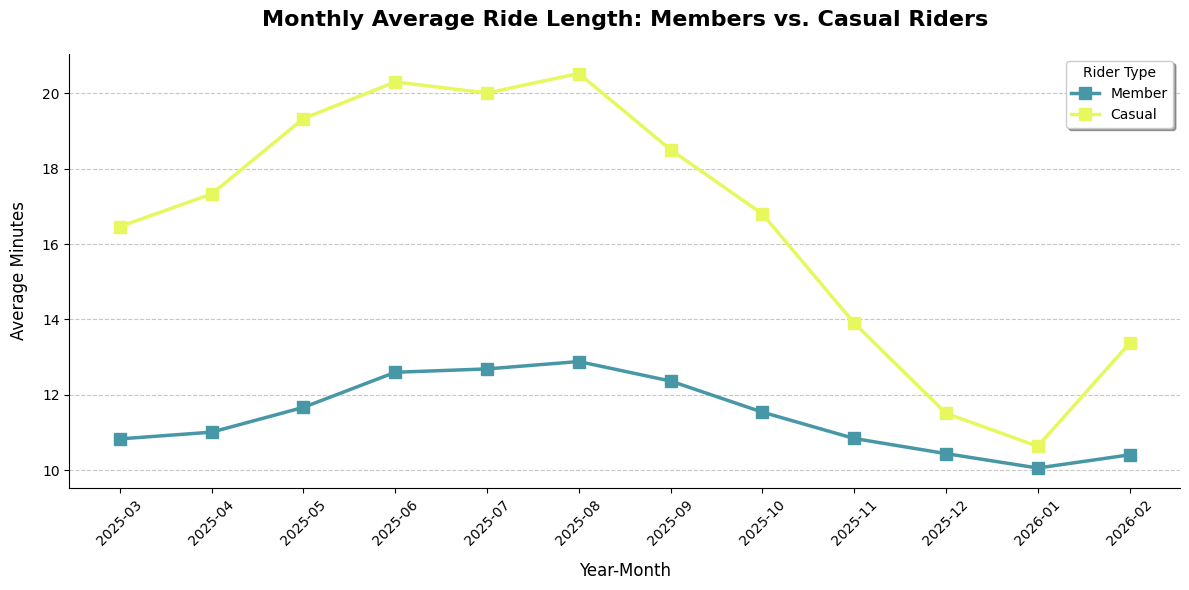

In [ ]:
colors = {'member': '#4797A6', 'casual': '#E6F85E'}

# --- 1. Monthly Trip Volume Chart ---
fig, ax = plt.subplots(figsize=(12, 6))

# Use a loop to ensure consistent coloring and markers
for rider_type in ['member', 'casual']:
    subset = monthly_trips[monthly_trips["member_casual"] == rider_type]
    ax.plot(subset["year_month"], subset["total_trips"], 
            marker="o", linewidth=2.5, markersize=8,
            label=rider_type.capitalize(), color=colors[rider_type])

# Professional Improvements
ax.set_title("Monthly Trip Volume: Members vs. Casual Riders", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Year-Month", fontsize=12, labelpad=10)
ax.set_ylabel("Total Trips", fontsize=12, labelpad=10)

# Custom Y-axis Formatter: e.g., 300,000 -> 300K
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x/1000)}K"))

# Aesthetic Cleanup
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis="x", rotation=45)

ax.legend(title="Rider Type", frameon=True, shadow=True)
plt.tight_layout()
plt.savefig(VIS_DIR / "02_monthly_trip_volume_pro.png", dpi=300, bbox_inches="tight")
plt.show()


# --- 2. Monthly Average Ride Length Chart ---
fig, ax = plt.subplots(figsize=(12, 6))

for rider_type in ['member', 'casual']:
    subset = monthly_avg[monthly_avg["member_casual"] == rider_type]
    ax.plot(subset["year_month"], subset["avg_ride_minutes"], 
            marker="s", linewidth=2.5, markersize=8, # Square markers for variety
            label=rider_type.capitalize(), color=colors[rider_type])

ax.set_title("Monthly Average Ride Length: Members vs. Casual Riders", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Year-Month", fontsize=12, labelpad=10)
ax.set_ylabel("Average Minutes", fontsize=12, labelpad=10)

# Aesthetic Cleanup
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis="x", rotation=45)

ax.legend(title="Rider Type", frameon=True, shadow=True)
plt.tight_layout()
plt.savefig(VIS_DIR / "03_monthly_avg_ride_length_pro.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Day-of-week patterns

This section helps reveal whether:
- members show more weekday/commute behavior
- casual riders concentrate on weekends and leisure periods


In [19]:
# --- Day-of-week summaries ---
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

dow_counts = (
    df.groupby(["day_name", "member_casual"])
      .size()
      .reset_index(name="total_trips")
)
dow_counts["day_name"] = pd.Categorical(dow_counts["day_name"], categories=day_order, ordered=True)
dow_counts = dow_counts.sort_values(["day_name", "member_casual"])

dow_avg = (
    df.groupby(["day_name", "member_casual"])["ride_length"]
      .mean()
      .reset_index(name="avg_ride_minutes")
)
dow_avg["day_name"] = pd.Categorical(dow_avg["day_name"], categories=day_order, ordered=True)
dow_avg = dow_avg.sort_values(["day_name", "member_casual"])

display(dow_counts.head(10))
display(dow_avg.head(10))

dow_counts.to_csv(SUMMARY_DIR / "day_of_week_trip_counts.csv", index=False)
dow_avg.to_csv(SUMMARY_DIR / "day_of_week_avg_ride_length.csv", index=False)


,day_name,member_casual,total_trips
6,Sunday,casual,318209
7,Sunday,member,374594
2,Monday,casual,220900
3,Monday,member,496329
10,Tuesday,casual,218954
11,Tuesday,member,563203
12,Wednesday,casual,214053
13,Wednesday,member,548727
8,Thursday,casual,248272
9,Thursday,member,566987


,day_name,member_casual,avg_ride_minutes
6,Sunday,casual,21.51
7,Sunday,member,12.96
2,Monday,casual,18.54
3,Monday,member,11.45
10,Tuesday,casual,16.32
11,Tuesday,member,11.45
12,Wednesday,casual,15.44
13,Wednesday,member,11.34
8,Thursday,casual,16.28
9,Thursday,member,11.45


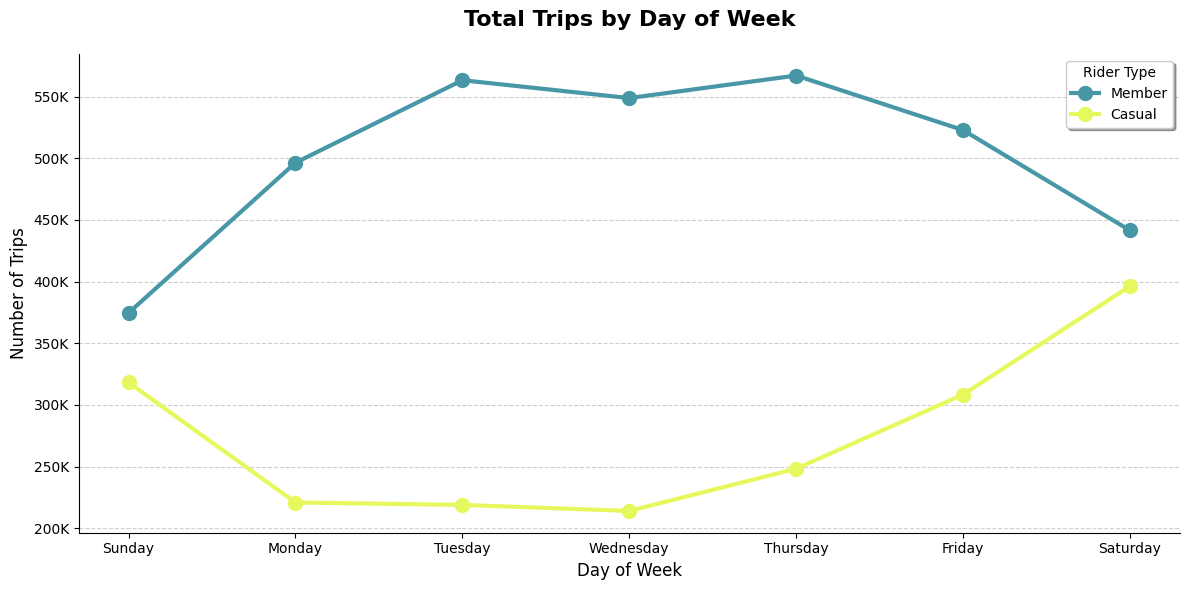

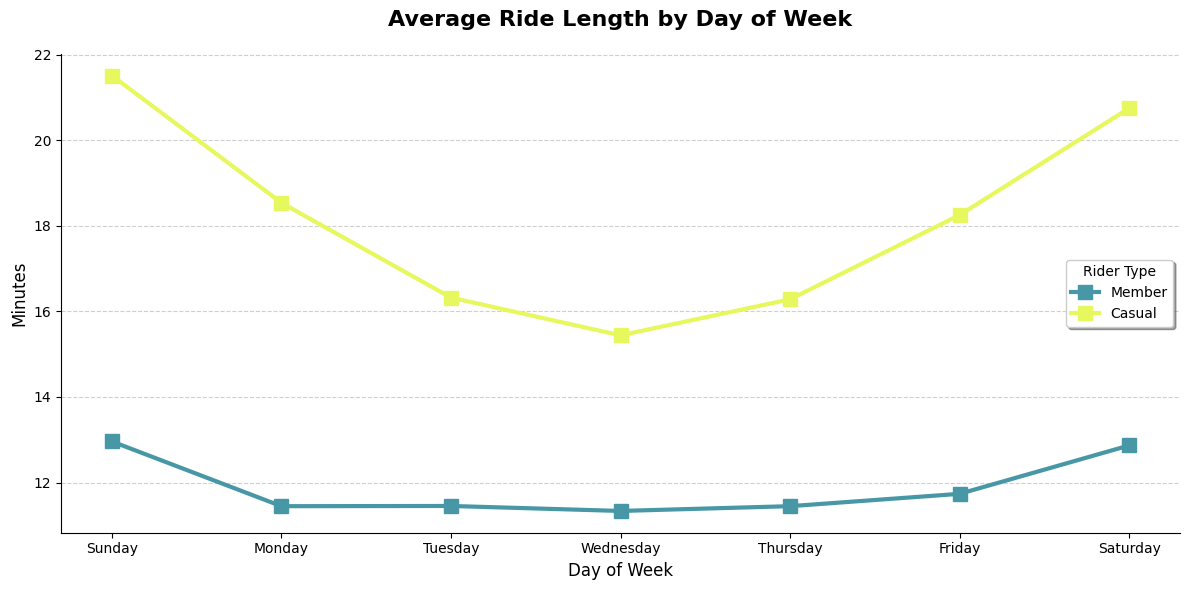

In [22]:
# CRITICAL: Ensure correct day-of-week order (Sunday to Saturday)
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

# --- 1. Trips by Day of Week ---
fig, ax = plt.subplots(figsize=(12, 6))

for rider_type in ['member', 'casual']:
    # Sort data logically by the day_order list
    subset = dow_counts[dow_counts["member_casual"] == rider_type].copy()
    subset['day_name'] = pd.Categorical(subset['day_name'], categories=day_order, ordered=True)
    subset = subset.sort_values("day_name")
    
    ax.plot(subset["day_name"], subset["total_trips"], 
            marker="o", linewidth=3, markersize=10,
            label=rider_type.capitalize(), color=colors[rider_type])

# Professional Polish
ax.set_title("Total Trips by Day of Week", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Day of Week", fontsize=12)
ax.set_ylabel("Number of Trips", fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x/1000)}K"))

ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title="Rider Type", frameon=True, shadow=True)

plt.tight_layout()
plt.savefig(VIS_DIR / "04_day_of_week_trip_counts.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 2. Average Ride Length by Day of Week ---
fig, ax = plt.subplots(figsize=(12, 6))

for rider_type in ['member', 'casual']:
    subset = dow_avg[dow_avg["member_casual"] == rider_type].copy()
    subset['day_name'] = pd.Categorical(subset['day_name'], categories=day_order, ordered=True)
    subset = subset.sort_values("day_name")
    
    ax.plot(subset["day_name"], subset["avg_ride_minutes"], 
            marker="s", linewidth=3, markersize=10,
            label=rider_type.capitalize(), color=colors[rider_type])

ax.set_title("Average Ride Length by Day of Week", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Day of Week", fontsize=12)
ax.set_ylabel("Minutes", fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title="Rider Type", frameon=True, shadow=True)

plt.tight_layout()
plt.savefig(VIS_DIR / "05_day_of_week_avg_ride_length.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Hour-of-day behavior

This is one of the most useful sections for distinguishing commuting vs leisure usage.

The heatmaps below show trip density by:
- **hour of day**
- **day of week**
- split by rider type


In [23]:
# --- Hour x day heatmap prep ---
heatmap_data = {}
value_col = "ride_id" if "ride_id" in df.columns else "ride_length"

for rider_type in sorted(df["member_casual"].dropna().unique()):
    subset = df[df["member_casual"] == rider_type].copy()
    pivot = subset.pivot_table(
        index="day_name",
        columns="ride_hour",
        values=value_col,
        aggfunc="count",
        fill_value=0
    )
    pivot = pivot.reindex(day_order)
    heatmap_data[rider_type] = pivot
    pivot.to_csv(SUMMARY_DIR / f"heatmap_hour_day_{rider_type}.csv")

list(heatmap_data.keys())


['casual', 'member']

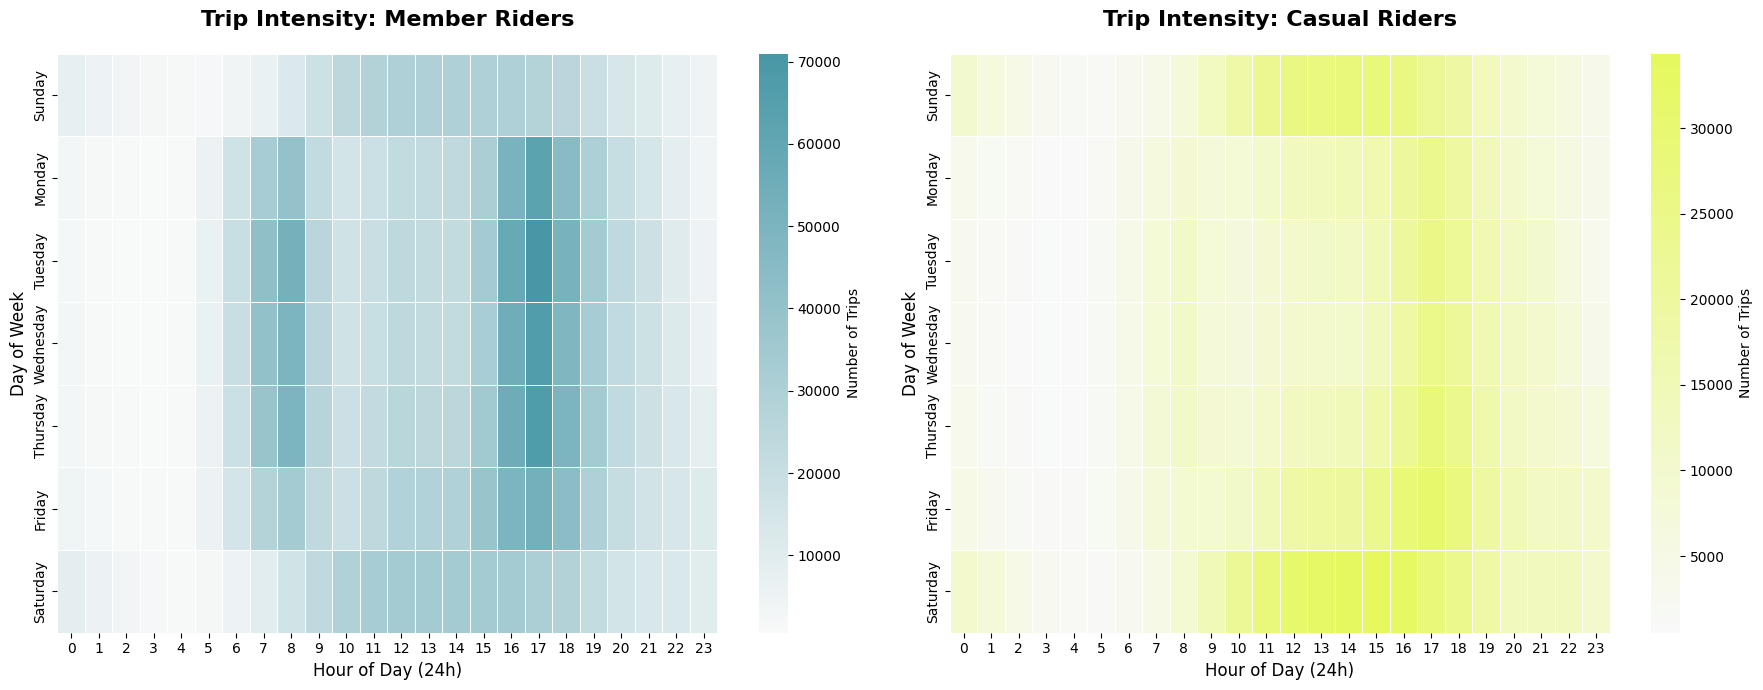

In [26]:
import matplotlib.colors as mcolors
import seaborn as sns 

day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, rider_type in enumerate(['member', 'casual']):
    ax = axes[idx]
    
    # Custom Colormap: Light grey/white to your brand color
    cmap = mcolors.LinearSegmentedColormap.from_list(
        f"{rider_type}_cmap", ["#F8F9F9", colors[rider_type]]
    )
    
    # Ensure categorical sorting for Day of Week
    pivot = heatmap_data[rider_type].reindex(day_order)
    
    # Plotting with Seaborn for cleaner axis handling
    sns.heatmap(pivot, ax=ax, cmap=cmap, cbar_kws={'label': 'Number of Trips'}, 
                linewidths=.5, linecolor='white')
    
    ax.set_title(f"Trip Intensity: {rider_type.title()} Riders", fontsize=16, pad=20, fontweight='bold')
    ax.set_xlabel("Hour of Day (24h)", fontsize=12)
    ax.set_ylabel("Day of Week", fontsize=12)

plt.tight_layout()
plt.savefig(VIS_DIR / "06_hour_day_heatmaps_pro.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Ride duration distribution

Average duration alone can hide the shape of rider behavior. Duration buckets make it easier to see whether members cluster in short routine trips while casual riders dominate longer rides.


In [ ]:
# --- Ride duration buckets ---
bins = [1, 5, 10, 20, 30, 60, 120, 240]
labels = ["1–5", "6–10", "11–20", "21–30", "31–60", "61–120", "121–240"]

df["ride_length_bucket"] = pd.cut(
    df["ride_length"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

duration_bucket_summary = (
    df.groupby(["ride_length_bucket", "member_casual"])
      .size()
      .reset_index(name="total_trips")
)

duration_bucket_summary["ride_length_bucket"] = pd.Categorical(
    duration_bucket_summary["ride_length_bucket"],
    categories=labels,
    ordered=True
)
duration_bucket_summary = duration_bucket_summary.sort_values(["ride_length_bucket", "member_casual"])

display(duration_bucket_summary.head(12))
duration_bucket_summary.to_csv(SUMMARY_DIR / "ride_length_bucket_summary.csv", index=False)


,ride_length_bucket,member_casual,total_trips
0,1–5,casual,276991
1,1–5,member,816449
2,6–10,casual,531642
3,6–10,member,1184093
4,11–20,casual,583383
5,11–20,member,1016439
6,21–30,casual,237202
7,21–30,member,307978
8,31–60,casual,207401
9,31–60,member,169247


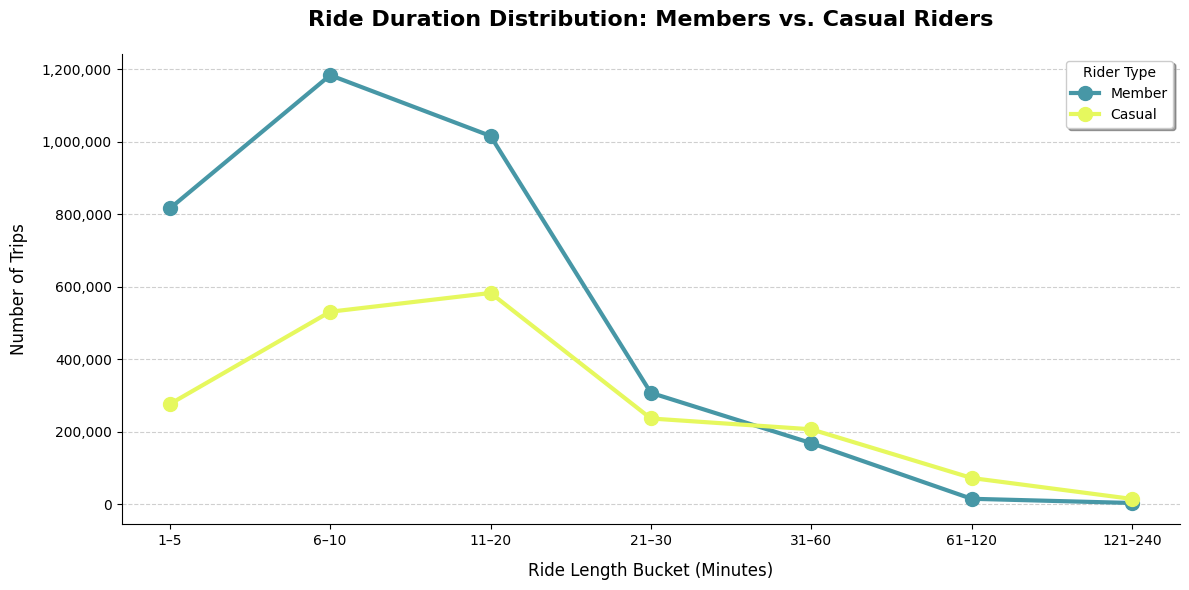

In [29]:
bucket_order = ["1–5", "6–10", "11–20", "21–30", "31–60", "61–120", "121–240"]

fig, ax = plt.subplots(figsize=(12, 6))

for rider_type in ['member', 'casual']:
    # Ensure buckets are sorted logically using categorical types
    subset = duration_bucket_summary[duration_bucket_summary["member_casual"] == rider_type].copy()
    subset["ride_length_bucket"] = pd.Categorical(subset["ride_length_bucket"], categories=bucket_order, ordered=True)
    subset = subset.sort_values("ride_length_bucket")
    
    # Plotting with thicker lines and larger markers
    ax.plot(subset["ride_length_bucket"].astype(str), subset["total_trips"], 
            marker="o", linewidth=3, markersize=10,
            label=rider_type.capitalize(), color=colors[rider_type])

# Professional Polish
ax.set_title("Ride Duration Distribution: Members vs. Casual Riders", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Ride Length Bucket (Minutes)", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Trips", fontsize=12, labelpad=10)

# Y-axis formatting with commas (e.g., 1,000,000)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

# Aesthetic Cleanup
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title="Rider Type", frameon=True, shadow=True)

plt.tight_layout()
plt.savefig(VIS_DIR / "07_ride_length_distribution_pro.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Bike type and round-trip behavior

These comparisons help clarify whether one rider type is more likely to:
- choose electric vs classic bikes
- use bikes for loop rides rather than point-to-point travel


In [30]:
# --- Bike type mix ---
bike_mix = (
    df.groupby(["member_casual", "rideable_type"])
      .size()
      .reset_index(name="total_trips")
)
bike_mix["trip_share_pct_within_rider"] = (
    bike_mix["total_trips"] / bike_mix.groupby("member_casual")["total_trips"].transform("sum") * 100
)

round_trip_summary = (
    df.groupby("member_casual")["is_round_trip"]
      .mean()
      .reset_index(name="round_trip_share_pct")
)
round_trip_summary["round_trip_share_pct"] *= 100

display(bike_mix)
display(round_trip_summary.round(2))

bike_mix.to_csv(SUMMARY_DIR / "bike_type_mix.csv", index=False)
round_trip_summary.to_csv(SUMMARY_DIR / "round_trip_summary.csv", index=False)


,member_casual,rideable_type,total_trips,trip_share_pct_within_rider
0,casual,classic_bike,667347,34.67
1,casual,electric_bike,1257746,65.33
2,member,classic_bike,1277491,36.35
3,member,electric_bike,2236578,63.65


,member_casual,round_trip_share_pct
0,casual,15.45
1,member,9.87


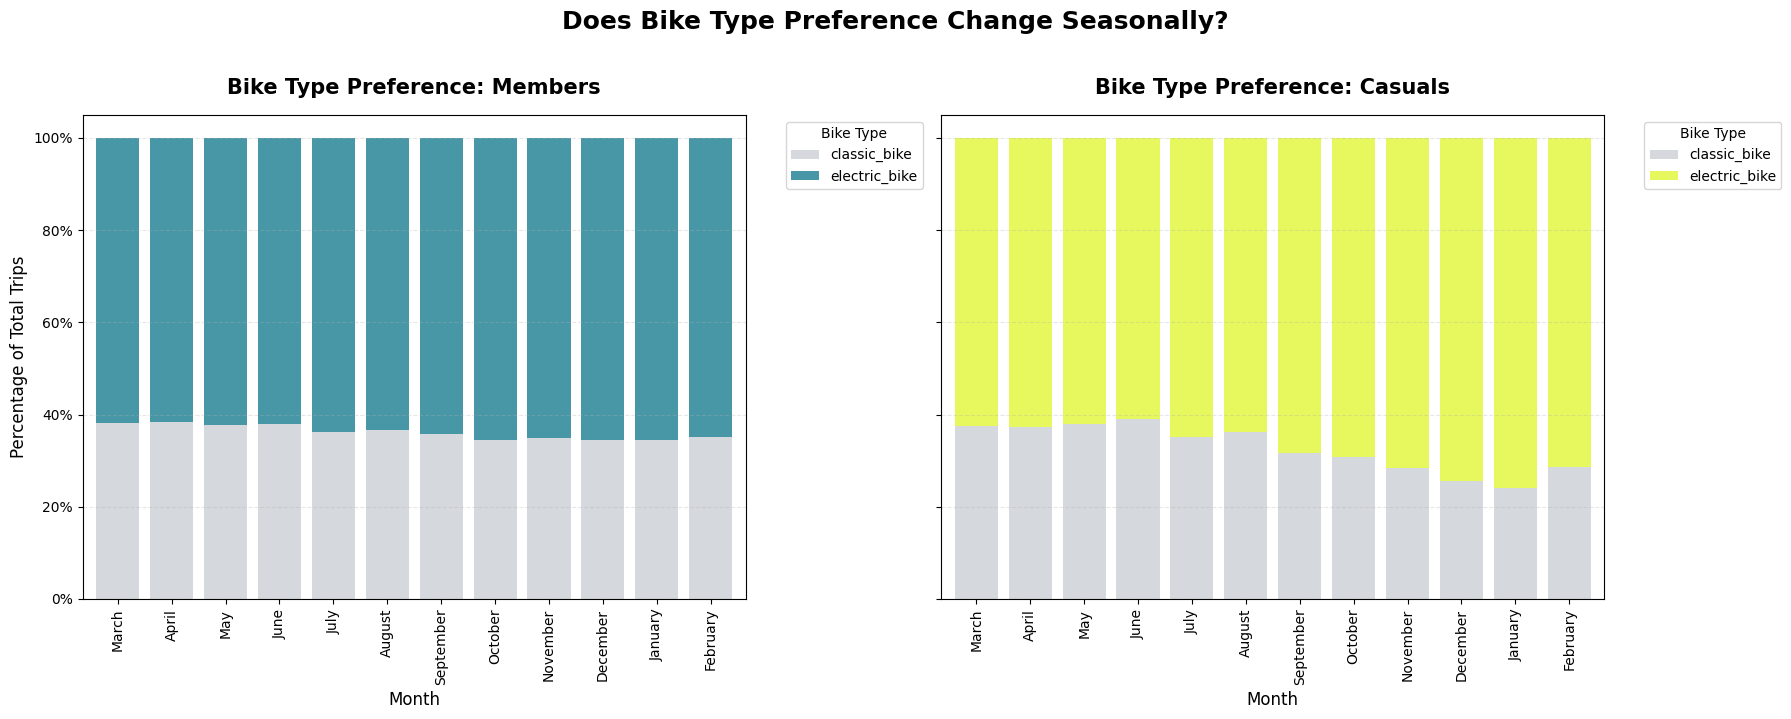

,ride_month,month_name,member_casual,rideable_type,trip_count,pct_share
0,1,January,casual,classic_bike,5744,24.13
1,1,January,casual,electric_bike,18056,75.87
4,2,February,casual,classic_bike,11484,28.69
5,2,February,casual,electric_bike,28538,71.31
8,3,March,casual,classic_bike,31084,37.58
9,3,March,casual,electric_bike,51625,62.42
12,4,April,casual,classic_bike,39220,37.33
13,4,April,casual,electric_bike,65837,62.67
16,5,May,casual,classic_bike,66494,37.95
17,5,May,casual,electric_bike,108736,62.05


In [32]:
from matplotlib.ticker import PercentFormatter

# 2. Group by month and bike type
# We include ride_month for sorting and month_name for labeling
seasonal_bike = df.groupby(
    ['ride_month', 'month_name', 'member_casual', 'rideable_type']
).size().reset_index(name='trip_count')

# 3. Calculate the percentage share of bike types within each month/user group
seasonal_bike['pct_share'] = seasonal_bike.groupby(
    ['ride_month', 'member_casual']
)['trip_count'].transform(lambda x: (x / x.sum()) * 100)

# 4. Visualization: Stacked Bar Chart for Seasonal Trends
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Define sub-palette to stay within brand feel
# Electric: Brand colors | Classic: Neutral Greys
bike_colors = {"electric_bike": "#4797A6", "classic_bike": "#D5D8DC"} # For Members
# For Casuals we can use the Lime color
casual_bike_colors = {"electric_bike": "#E6F85E", "classic_bike": "#D5D8DC"}

user_types = ['member', 'casual']
palette_list = [bike_colors, casual_bike_colors]

for i, user in enumerate(user_types):
    ax = axes[i]
    subset = seasonal_bike[seasonal_bike['member_casual'] == user]
    
    # Pivot for plotting
    plot_data = subset.pivot(index='month_name', columns='rideable_type', values='pct_share')
    # Re-order index to follow calendar months
    month_order = ["March", "April", "May", "June", "July", "August", 
                   "September", "October", "November", "December", "January", "February"]
    plot_data = plot_data.reindex(month_order)
    
    plot_data.plot(kind='bar', stacked=True, ax=ax, color=palette_list[i], width=0.8)
    
    ax.set_title(f"Bike Type Preference: {user.title()}s", fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel("Percentage of Total Trips", fontsize=12)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.legend(title="Bike Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle("Does Bike Type Preference Change Seasonally?", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(VIS_DIR / "08_seasonal_bike_preference.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Display the numeric breakdown for the final report
display(seasonal_bike.sort_values(['member_casual', 'ride_month']))

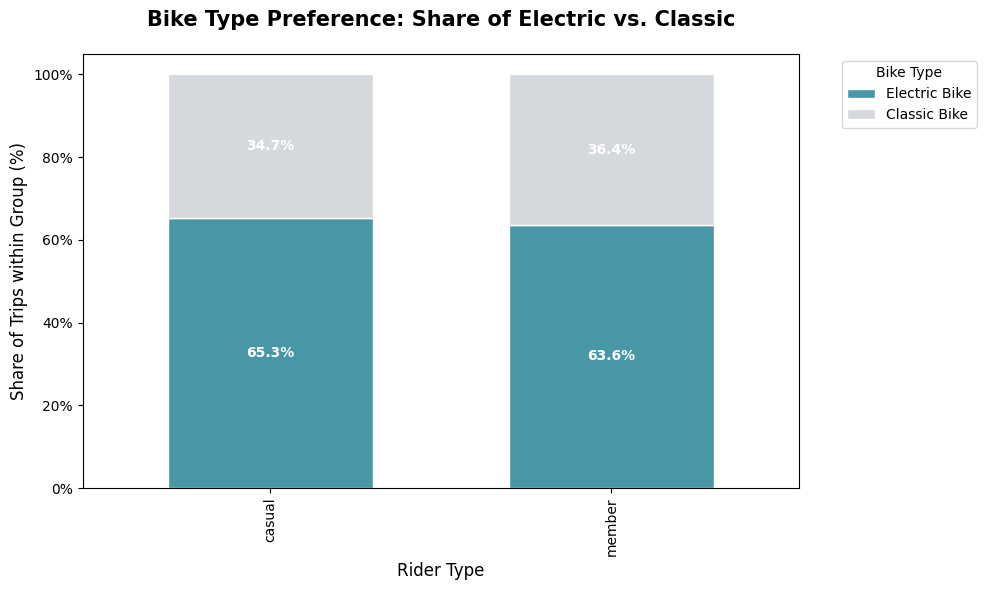

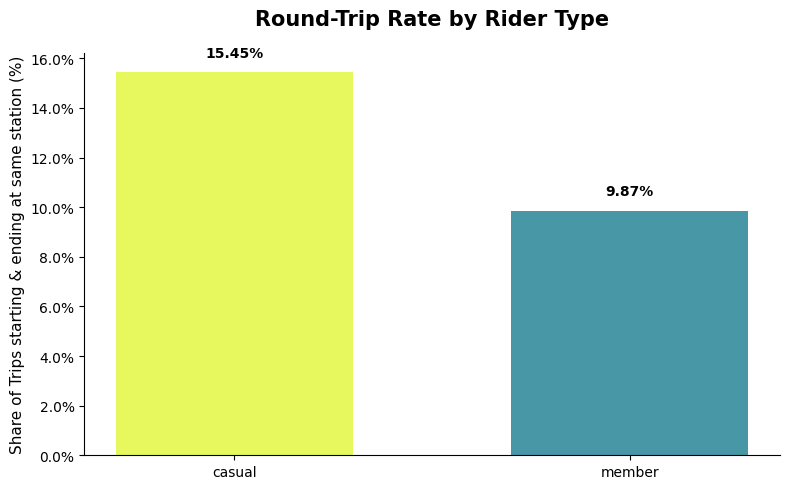

In [34]:

# Neutral grey for the secondary bike type to let brand colors stand out
neutral_grey = '#D5D8DC' 

# --- 1. Plot Bike Type Mix (Stacked Bar Chart) ---
fig, ax = plt.subplots(figsize=(10, 6))

# Pivot data for stacked bar: rows=member_casual, columns=rideable_type
pivot_bike = bike_mix.pivot(index='member_casual', columns='rideable_type', values='trip_share_pct_within_rider')

# Reorder so Electric is on bottom for better visual weight
pivot_bike = pivot_bike[['electric_bike', 'classic_bike']]

# Plot
pivot_bike.plot(kind='bar', stacked=True, ax=ax, 
                color=[colors['member'], neutral_grey], # Note: This will need logic if doing side-by-side
                edgecolor='white', width=0.6)

# Refined labels and styling
ax.set_title("Bike Type Preference: Share of Electric vs. Classic", fontsize=15, pad=20, fontweight='bold')
ax.set_ylabel("Share of Trips within Group (%)", fontsize=12)
ax.set_xlabel("Rider Type", fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(["Electric Bike", "Classic Bike"], title="Bike Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(VIS_DIR / "08_bike_type_mix_pro.png", dpi=300, bbox_inches="tight")
plt.show()


# --- 2. Plot Round-Trip Share ---
fig, ax = plt.subplots(figsize=(8, 5))

# Use the specific brand colors for the individual bars
bars = ax.bar(round_trip_summary["member_casual"], 
              round_trip_summary["round_trip_share_pct"], 
              color=[colors['casual'], colors['member']], # Order based on your dataframe
              width=0.6)

ax.set_title("Round-Trip Rate by Rider Type", fontsize=15, pad=20, fontweight='bold')
ax.set_ylabel("Share of Trips starting & ending at same station (%)", fontsize=11)
ax.yaxis.set_major_formatter(PercentFormatter())

# Clean up chartjunk
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(VIS_DIR / "09_round_trip_share_pro.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Station analysis

Station-based analysis is useful, but remember the Process phase documented that station IDs/names remain partially null because many valid trips do not begin or end at traditional docking stations. Station analysis should therefore be interpreted as a **partial spatial view**, not a complete location census.

To reduce noise, the summaries below use only rows with a non-null start station name.


In [8]:
# --- Station analysis ---
station_df = df[df["start_station_name"].notna() & (df["start_station_name"].astype(str).str.strip() != "")].copy()

top_stations_member = (
    station_df[station_df["member_casual"] == "member"]
    .groupby("start_station_name")
    .size()
    .reset_index(name="total_trips")
    .sort_values("total_trips", ascending=False)
    .head(15)
)

top_stations_casual = (
    station_df[station_df["member_casual"] == "casual"]
    .groupby("start_station_name")
    .size()
    .reset_index(name="total_trips")
    .sort_values("total_trips", ascending=False)
    .head(15)
)

station_mix = (
    station_df.groupby(["start_station_name", "member_casual"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["member", "casual"]:
    if col not in station_mix.columns:
        station_mix[col] = 0

station_mix["total_trips"] = station_mix["member"] + station_mix["casual"]
station_mix["casual_share_pct"] = np.where(
    station_mix["total_trips"] > 0,
    station_mix["casual"] / station_mix["total_trips"] * 100,
    0
)

casual_heavy_stations = (
    station_mix[station_mix["total_trips"] >= 1000]
    .sort_values(["casual_share_pct", "total_trips"], ascending=[False, False])
    .head(20)
)

display(top_stations_member.head(10))
display(top_stations_casual.head(10))
display(casual_heavy_stations.head(10))

top_stations_member.to_csv(SUMMARY_DIR / "top_start_stations_member.csv", index=False)
top_stations_casual.to_csv(SUMMARY_DIR / "top_start_stations_casual.csv", index=False)
casual_heavy_stations.to_csv(SUMMARY_DIR / "casual_heavy_stations.csv", index=False)


,start_station_name,total_trips
569,Kingsbury St & Kinzie St,27849
234,Clinton St & Washington Blvd,24443
147,Canal St & Madison St,22079
230,Clinton St & Madison St,21319
201,Clark St & Elm St,19867
1628,State St & Chicago Ave,18980
1721,Wells St & Elm St,18690
228,Clinton St & Jackson Blvd,18254
1720,Wells St & Concord Ln,18226
1724,Wells St & Huron St,17759


,start_station_name,total_trips
328,DuSable Lake Shore Dr & Monroe St,30808
811,Navy Pier,27548
1551,Streeter Dr & Grand Ave,22862
758,Michigan Ave & Oak St,22054
329,DuSable Lake Shore Dr & North Blvd,19099
765,Millennium Park,18719
1448,Shedd Aquarium,16558
1556,Theater on the Lake,15525
332,Dusable Harbor,15337
753,Michigan Ave & 8th St,10976


member_casual,start_station_name,casual,member,total_trips,casual_share_pct
1617,Shedd Aquarium,16558,3678,20236,81.82
378,Field Museum,9806,2259,12065,81.28
1720,Streeter Dr & Grand Ave,22862,5911,28773,79.46
329,DuSable Lake Shore Dr & Monroe St,30808,8243,39051,78.89
813,Navy Pier,27548,8146,35694,77.18
333,Dusable Harbor,15337,5513,20850,73.56
18,Adler Planetarium,9935,3734,13669,72.68
737,McCormick Place,4944,1862,6806,72.64
1721,Streeter Dr/Grand Ave,2447,950,3397,72.03
766,Millennium Park,18719,8420,27139,68.97


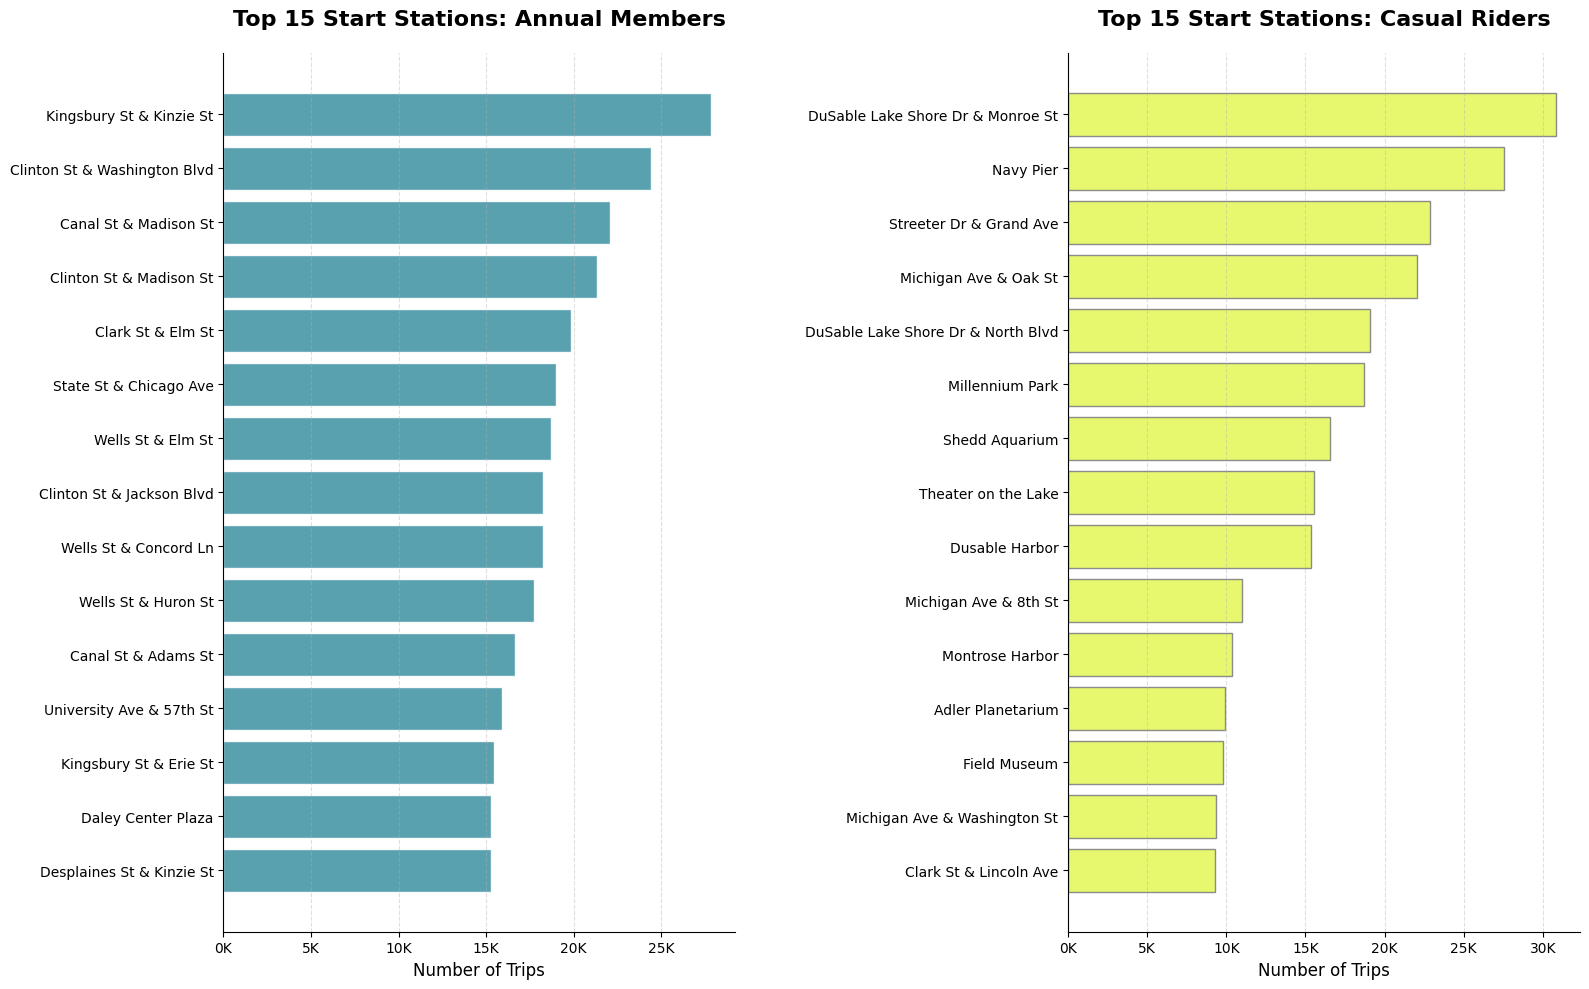

In [10]:

colors = {'member': '#4797A6', 'casual': '#E6F85E'}

# Create the figure with two horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 1. Plot Top Stations for Members (Teal)
# Reverse the data to show the highest at the top of the horizontal bar chart
member_data = top_stations_member.iloc[:15][::-1] 
axes[0].barh(member_data["start_station_name"], 
            member_data["total_trips"], 
            color=colors['member'],
            edgecolor='white', alpha=0.9)

axes[0].set_title("Top 15 Start Stations: Annual Members", fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel("Number of Trips", fontsize=12)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x/1000)}K"))
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 2. Plot Top Stations for Casual Riders (Lime)
casual_data = top_stations_casual.iloc[:15][::-1]
axes[1].barh(casual_data["start_station_name"], 
            casual_data["total_trips"], 
            color=colors['casual'],
            edgecolor='grey', alpha=0.9)

axes[1].set_title("Top 15 Start Stations: Casual Riders", fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel("Number of Trips", fontsize=12)
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x/1000)}K"))
axes[1].grid(axis='x', linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Optimize spacing to ensure station names don't overlap or get cut off
plt.tight_layout(w_pad=5)
plt.savefig(VIS_DIR / "10_top_start_stations_pro.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# %pip install folium

In [ ]:
# --- Top Stations with Coordinates ---

# 1. Member Top Stations
top_stations_member = df[df['member_casual'] == 'member'].groupby('start_station_name').agg(
    total_trips=('ride_id', 'count'),
    lat=('start_lat', 'mean'),
    lng=('start_lng', 'mean')
).reset_index().sort_values('total_trips', ascending=False).head(15)

# 2. Casual Top Stations
top_stations_casual = df[df['member_casual'] == 'casual'].groupby('start_station_name').agg(
    total_trips=('ride_id', 'count'),
    lat=('start_lat', 'mean'),
    lng=('start_lng', 'mean')
).reset_index().sort_values('total_trips', ascending=False).head(15)

print("Updated Member Columns:", top_stations_member.columns.tolist())

Updated Member Columns: ['start_station_name', 'total_trips', 'lat', 'lng']


In [23]:
import folium
from folium import plugins
import pandas as pd

# 1. Configuration & Colors
# Member: #4797A6 | Casual: #E6F85E
brand_colors = {'member': '#4797A6', 'casual': '#E6F85E'}
chicago_coords = [41.8781, -87.6298] # Center point for Chicago

# 2. Create the Base Map
# Using 'cartodbpositron' for a clean, professional look that makes colors pop
m = folium.Map(location=chicago_coords, zoom_start=12, tiles="cartodbpositron")

# 3. Add Station Markers
# Note: replace 'stations_df' with your specific station summary dataframe
def add_station_markers(df, rider_type, map_obj):
    for _, row in df.iterrows():
        # Using the new column names 'lat' and 'lng'
        folium.CircleMarker(
            location=[row['lat'], row['lng']], 
            radius=row['total_trips'] / 1500, # Tweaked scale for visibility
            popup=f"Station: {row['start_station_name']}<br>Trips: {int(row['total_trips']):,}",
            color=brand_colors[rider_type],
            fill=True,
            fill_color=brand_colors[rider_type],
            fill_opacity=0.7
        ).add_to(map_obj)

# Now call them again
add_station_markers(top_stations_member, 'member', m)
add_station_markers(top_stations_casual, 'casual', m)

# 4. Optional: Add a Heatmap Layer for Density
# heat_data = df[['start_lat', 'start_lng']].values.tolist()
# plugins.HeatMap(heat_data, radius=15).add_to(m)

# 5. Save the Map
m.save("cyclistic_geographic_context.html")
print("Map saved as 'cyclistic_geographic_context.html'. Open it in your browser to view!")

Map saved as 'cyclistic_geographic_context.html'. Open it in your browser to view!



## 9. Conversion opportunity lens: commuter-like casual riders

A simple proxy for **commuter-like casual riders** is:
- casual rider
- weekday trip
- hour in peak windows (7–9 AM or 4–6 PM)
- shorter rides (for example, 20 minutes or less)
- not a round trip

This is not a perfect customer-level classification, but it identifies trips that *behave more like routine mobility than leisure*.


In [ ]:
# 1. Identify "Member Hubs" (Top 20 stations for existing members)
member_hubs = top_stations_member['start_station_name'].head(20).tolist()

# 2. Define the Peak Hour window
peak_hours = {7, 8, 9, 16, 17, 18}

# 3. Apply the Conversion Lens
casual_df = df[df["member_casual"] == "casual"].copy()

# Logic for refined segments
conditions = [
    # SEGMENT 1: High-Priority Target (The "Commuter Mimic")
    # Acting exactly like a member: Weekday, Peak, Short, and at a Member Hub
    (casual_df["is_weekend"] == False) & 
    (casual_df["ride_hour"].isin(peak_hours)) & 
    (casual_df["ride_length"] <= 20) & 
    (casual_df["is_round_trip"] == False) &
    (casual_df["start_station_name"].isin(member_hubs)),

    # SEGMENT 2: Potential Commuter
    # Same as above, but starting from a non-hub station
    (casual_df["is_weekend"] == False) & 
    (casual_df["ride_hour"].isin(peak_hours)) & 
    (casual_df["ride_length"] <= 20) & 
    (casual_df["is_round_trip"] == False) &
    (~casual_df["start_station_name"].isin(member_hubs)),

    # SEGMENT 3: Weekend Warrior
    # High frequency on weekends, likely recreational but repeated
    (casual_df["is_weekend"] == True) & 
    (casual_df["ride_length"] > 20),

    # SEGMENT 4: Tourist / Explorer
    # Round trips or extremely long durations
    (casual_df["is_round_trip"] == True)
]

choices = [
    "High-Priority Target (Commuter Mimic)",
    "Standard Commuter (Non-Hub)",
    "Weekend Leisure",
    "Round-Trip Explorer"
]

casual_df["conversion_potential"] = np.select(conditions, choices, default="Occasional/Other")

# 4. Generate the Strategy Summary
conversion_summary = (
    casual_df.groupby("conversion_potential")
    .agg(
        total_trips=("ride_id", "count"),
        avg_duration=("ride_length", "mean"),
        electric_share=("rideable_type", lambda x: (x == "electric_bike").mean() * 100)
    )
    .reset_index()
    .sort_values("total_trips", ascending=False)
)

# Calculate Opportunity Share
total_casuals = conversion_summary["total_trips"].sum()
conversion_summary["opportunity_share_%"] = (conversion_summary["total_trips"] / total_casuals * 100)

display(conversion_summary.round(2))
conversion_summary.to_csv(SUMMARY_DIR / "conversion_potential_summary.csv", index=False)

,conversion_potential,total_trips,avg_duration,electric_share,opportunity_share_%
1,Occasional/Other,1089985,16.58,63.84,56.62
3,Standard Commuter (Non-Hub),307304,9.47,71.60,15.96
2,Round-Trip Explorer,258203,15.99,79.68,13.41
4,Weekend Leisure,239457,43.12,48.18,12.44
0,High-Priority Target (Commuter Mimic),30144,8.88,68.92,1.57



## 10. Exported summary tables and analysis notes

The cells below generate:
- machine-readable CSV summaries for Power BI or presentation use
- a JSON file containing a small set of reusable headline metrics
- a draft list of candidate insights to refine in the Share / Act phases


In [28]:

# --- Headline metrics for reuse ---
headline_metrics = {
    "dataset_rows": int(len(df)),
    "dataset_columns": int(df.shape[1]),
    "member_total_trips": int((df["member_casual"] == "member").sum()),
    "casual_total_trips": int((df["member_casual"] == "casual").sum()),
    "member_avg_ride_minutes": float(df.loc[df["member_casual"] == "member", "ride_length"].mean()),
    "casual_avg_ride_minutes": float(df.loc[df["member_casual"] == "casual", "ride_length"].mean()),
    "member_median_ride_minutes": float(df.loc[df["member_casual"] == "member", "ride_length"].median()),
    "casual_median_ride_minutes": float(df.loc[df["member_casual"] == "casual", "ride_length"].median()),
}

with open(SUMMARY_DIR / "headline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(headline_metrics, f, indent=2)

headline_metrics


{'dataset_rows': 5439162,
 'dataset_columns': 28,
 'member_total_trips': 3514069,
 'casual_total_trips': 1925093,
 'member_avg_ride_minutes': 11.813629344348865,
 'casual_avg_ride_minutes': 18.549724295778613,
 'member_median_ride_minutes': 8.748883333333334,
 'casual_median_ride_minutes': 11.858816666666666}

### Important limitation
This dataset explains **how** riders behave differently, but not fully **why** they choose membership. The data is trip-level and anonymized, so it cannot directly connect usage behavior to individual purchase motivations.
